# Глава 2


## 2.1 Импорт библиотек и БД

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_mono_known = pd.read_excel('../data/df_mono_known.xlsx')
df_nomono_known = pd.read_excel('../data/df_nomono_known.xlsx')
df_all = pd.read_excel('../data/df_all.xlsx')

## 2.2 Описательная статистика

In [2]:
n_mono   = len(df_all[df_all['group'] == 'МОНО'])
n_nomono = len(df_all[df_all['group'] == 'БЕЗ МОНО'])
df_mono_s   = df_all[df_all['group'] == 'МОНО']
df_nomono_s = df_all[df_all['group'] == 'БЕЗ МОНО']

In [3]:
print(f"МОНО (n={n_mono})")
print(f"  Мужчины:         {(df_mono_s['Gender'] == 'м').sum()/n_mono*100:.1f}%")
print(f"  Женщины:         {(df_mono_s['Gender'] == 'ж').sum()/n_mono*100:.1f}%")
print(f"  Средний возраст: {df_mono_s['Age'].mean():.1f} ± {df_mono_s['Age'].std():.1f} лет")
print(f"  Летальность:     {df_mono_s['dead'].mean()*100:.1f}%")

МОНО (n=2754)
  Мужчины:         42.8%
  Женщины:         57.2%
  Средний возраст: 64.2 ± 15.4 лет
  Летальность:     26.5%


In [4]:
print(f"\nБЕЗ МОНО (n={n_nomono})")
print(f"  Мужчины:         {(df_nomono_s['Gender'] == 'м').sum()/n_nomono*100:.1f}%")
print(f"  Женщины:         {(df_nomono_s['Gender'] == 'ж').sum()/n_nomono*100:.1f}%")
print(f"  Средний возраст: {df_nomono_s['Age'].mean():.1f} ± {df_nomono_s['Age'].std():.1f} лет")
print(f"  Летальность:     {df_nomono_s['dead'].mean()*100:.1f}%")


БЕЗ МОНО (n=6827)
  Мужчины:         39.2%
  Женщины:         60.8%
  Средний возраст: 65.7 ± 17.1 лет
  Летальность:     22.6%


C:\Users\User\AppData\Local\Temp\ipykernel_14560\212677227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x='group', y='Age', palette={'МОНО': 'royalblue', 'БЕЗ МОНО': 'darkorange'},


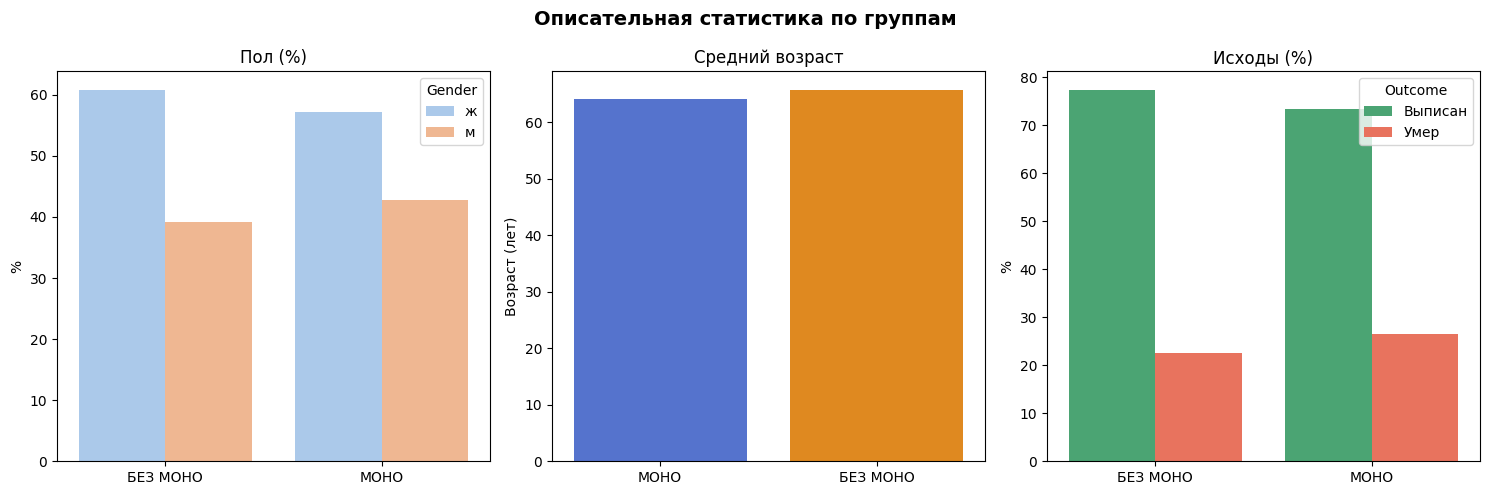

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Описательная статистика по группам', fontsize=14, fontweight='bold')

gender_pct = df_all.groupby('group')['Gender'].value_counts(normalize=True).mul(100).rename('pct').reset_index()
sns.barplot(data=gender_pct, x='group', y='pct', hue='Gender', palette='pastel', ax=axes[0])
axes[0].set(title='Пол (%)', ylabel='%', xlabel='')

sns.barplot(data=df_all, x='group', y='Age', palette={'МОНО': 'royalblue', 'БЕЗ МОНО': 'darkorange'}, 
            errorbar=None, ax=axes[1])
axes[1].set(title='Средний возраст', ylabel='Возраст (лет)', xlabel='')

outcome_pct = df_all.groupby('group')['Outcome'].value_counts(normalize=True).mul(100).rename('pct').reset_index()
sns.barplot(data=outcome_pct, x='group', y='pct', hue='Outcome', 
            palette={'Умер': 'tomato', 'Выписан': 'mediumseagreen'}, ax=axes[2])
axes[2].set(title='Исходы (%)', ylabel='%', xlabel='')

plt.tight_layout()
plt.show()

Видно, что возраст пациентов в обеих группах почти совпадает, количество женщин и мужчин примерно одинаково. Может показаться, что смертность в группе МОНО выше, чем в БЕЗ МОНО, но делать по этому выводы пока нельзя, т.к. логично, что лекарство назначается обычно тяжелым пациентам, поэтому в группе БЕЗ МОНО намного больше легко больных, и они скорее всего выздоравливают самостоятельно